In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Veriyi Yükleme
df = pd.read_csv('online_shoppers_intention.csv')

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


# --- VERİ ÖN İŞLEME ---

In [6]:
# 1. Eksik Veri Analizi
print("Eksik Veri Sayısı:\n", df.isnull().sum().sum()) # Veri seti genelde temizdir.

Eksik Veri Sayısı:
 0


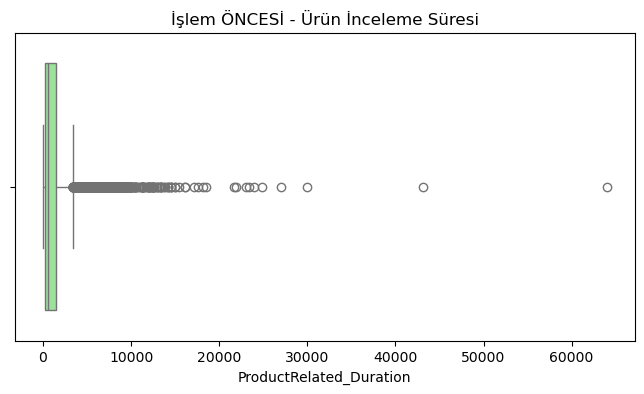

In [7]:
# 2. Aykırı Değer (Outlier) Gözlemi (İşlem Öncesi)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['ProductRelated_Duration'], color='lightgreen')
plt.title('İşlem ÖNCESİ - Ürün İnceleme Süresi')
plt.show()

In [8]:
# 3. AYKIRI DEĞER İŞLEME (99. Yüzdelik Dilim / Percentile Yöntemi)
# IQR yerine, sadece verinin en üst %1'lik uçuk kısmını tıraşlıyoruz
def cap_outliers_percentile(dataframe, column):
    upper_bound = dataframe[column].quantile(0.99) 
    dataframe[column] = dataframe[column].clip(upper=upper_bound)
    return dataframe

In [9]:
# Süre ve değer belirten sütunlarda işlemi uyguluyoruz
numerical_columns = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'PageValues']
for col in numerical_columns:
    df = cap_outliers_percentile(df, col)

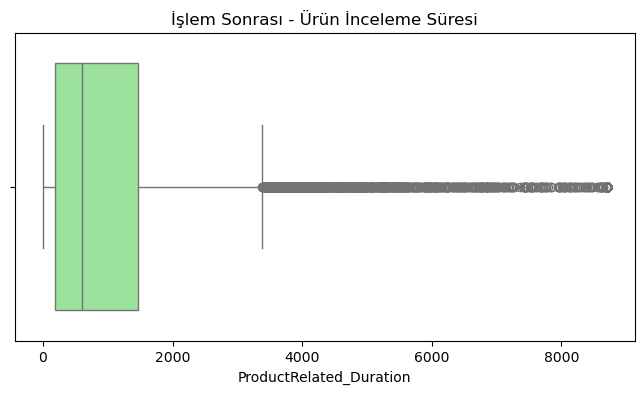

In [10]:
#İşlem Sonrası
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['ProductRelated_Duration'], color='lightgreen')
plt.title('İşlem Sonrası - Ürün İnceleme Süresi')
plt.show()

In [11]:
# 4. Kategorik Değişkenleri Sayısala Çevirme
df_encoded = pd.get_dummies(df, drop_first=True)

In [12]:
# 5. Feature Seçimi (X ve y ayrımı)
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

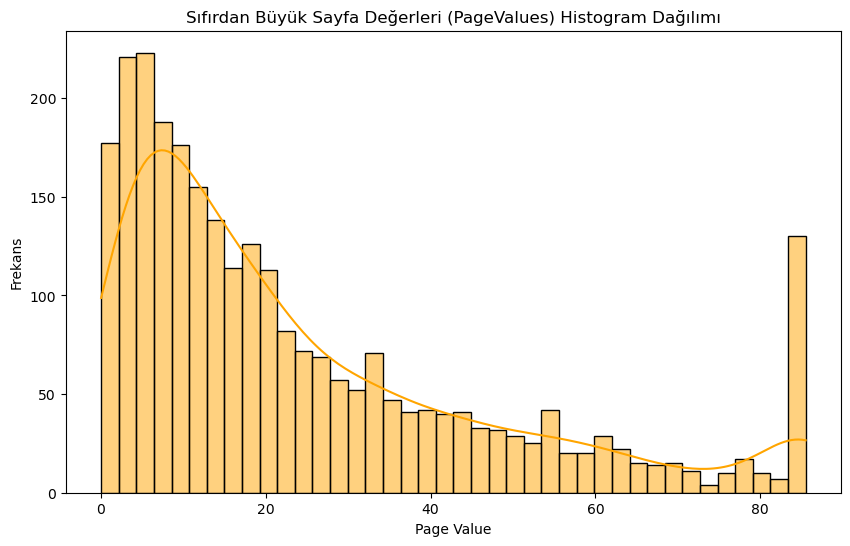

In [13]:
# --- VERİ GÖRSELLEŞTİRME ---

# İstenen Histogram Grafiği (Sayfa Değeri - PageValues dağılımı)
# Artık değerler 0'a eşitlenmediği için dağılımı net şekilde göreceğiz.
plt.figure(figsize=(10, 6))
sns.histplot(df[df['PageValues'] > 0]['PageValues'], bins=40, kde=True, color='orange')
plt.title('Sıfırdan Büyük Sayfa Değerleri (PageValues) Histogram Dağılımı')
plt.xlabel('Page Value')
plt.ylabel('Frekans')
plt.show()

In [14]:
# --- MODEL OLUŞTURMA VE HİPERPARAMETRE OPTİMİZASYONU ---

# 1. Train-test split (%70 Eğitim, %30 Test) ve random_state kullanımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [15]:
# 2. Pipeline Kurulumu
# Karar ağaçları normalde ölçeklemeye (StandardScaler) ihtiyaç duymaz, 
# ancak ödev yönergesindeki 'özellik ölçekleme' maddesini karşılamak için Pipeline'a ekliyoruz.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

In [16]:
# 3. GridSearchCV ile max_depth, min_samples_split ve min_samples_leaf analizi
# Ağacın derinliğini ve dallanma kurallarını optimize ediyoruz.
param_grid = {
    'dt__max_depth': [3, 5, 10, None],
    'dt__min_samples_split': [2, 10, 20],
    'dt__min_samples_leaf': [1, 5, 10]
}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)

print("GridSearchCV çalışıyor, en iyi parametreler aranıyor...")
grid_search.fit(X_train, y_train)

print("\nEn İyi Parametreler (GridSearch):", grid_search.best_params_)

# En iyi model ile tahmin yapalım (Budama öncesi ham model performansı için)
best_dt = grid_search.best_estimator_
y_pred_before = best_dt.predict(X_test)

GridSearchCV çalışıyor, en iyi parametreler aranıyor...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

En İyi Parametreler (GridSearch): {'dt__max_depth': 5, 'dt__min_samples_leaf': 10, 'dt__min_samples_split': 2}


In [17]:
# --- BUDAMA (PRUNING) VE GÖRSELLEŞTİRME ---

# 1. ccp_alpha kullanarak Pruning (Budama) yapılması
# Modelin overfitting (ezberleme) yapmasını önlemek için ideal alfa değerini arıyoruz.
dt_clf = DecisionTreeClassifier(random_state=42)
path = dt_clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# İdeal bir alfa değeri seçip (örneğin alphas listesinden makul bir değer veya manuel 0.001) 
# budanmış (pruned) modeli kuruyoruz.
pruned_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=0.001)
pruned_dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
# Budanmış model ile test verisinde tahmin yapıyoruz
y_pred_after = pruned_dt.predict(X_test)

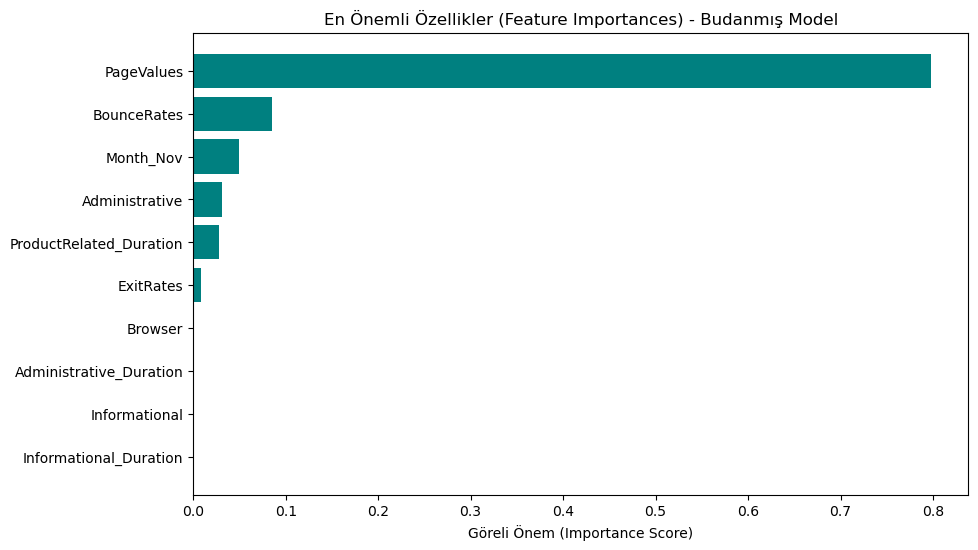

In [19]:
# 2. Özelliklerin Önemini (Feature Importance) Görselleştirme
importances = pruned_dt.feature_importances_
features = X.columns
indices = np.argsort(importances)[-10:] # Grafiği kalabalıklaştırmamak için en önemli 10 özelliği alıyoruz

plt.figure(figsize=(10, 6))
plt.title('En Önemli Özellikler (Feature Importances) - Budanmış Model')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Göreli Önem (Importance Score)')
plt.show()

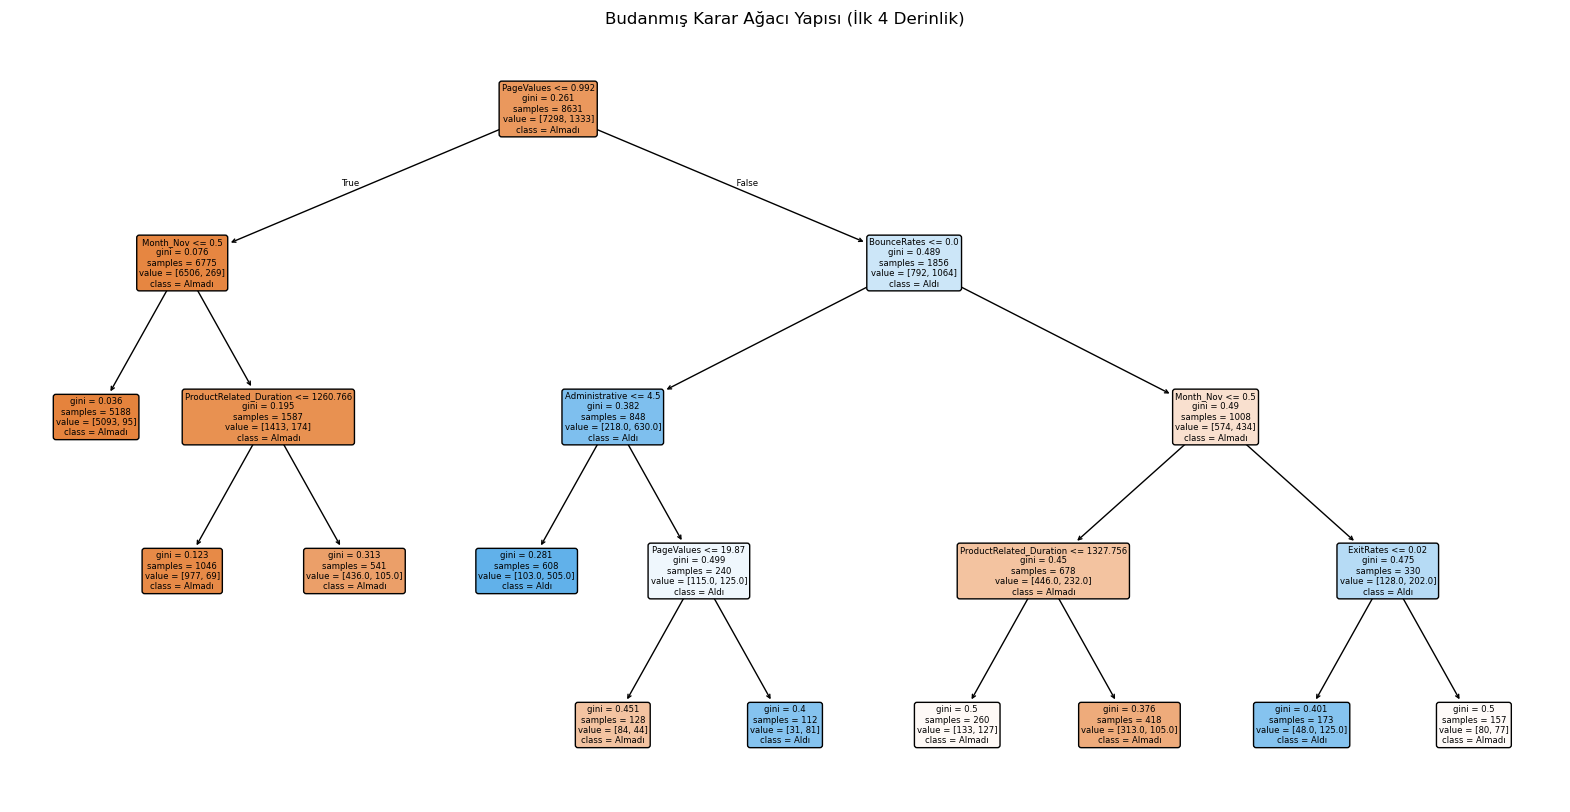

In [20]:
# 3. Ağaç Yapısını Görselleştirme (Tree Plot)
plt.figure(figsize=(20, 10))
# Ağacın tamamını çizdirmek çok karmaşık olacağı için max_depth=4 diyerek sadece tepeyi çizdiriyoruz
plot_tree(pruned_dt, filled=True, feature_names=X.columns, class_names=['Almadı', 'Aldı'], rounded=True, max_depth=4)
plt.title("Budanmış Karar Ağacı Yapısı (İlk 4 Derinlik)")
plt.show()

=== BUDAMA ÖNCESİ (GridSearch) PERFORMANS ===
              precision    recall  f1-score   support

       False       0.92      0.97      0.94      3124
        True       0.73      0.52      0.61       575

    accuracy                           0.90      3699
   macro avg       0.82      0.74      0.77      3699
weighted avg       0.89      0.90      0.89      3699


=== BUDAMA SONRASI (Pruned - ccp_alpha) PERFORMANS ===
              precision    recall  f1-score   support

       False       0.91      0.97      0.94      3124
        True       0.76      0.49      0.60       575

    accuracy                           0.90      3699
   macro avg       0.84      0.73      0.77      3699
weighted avg       0.89      0.90      0.89      3699



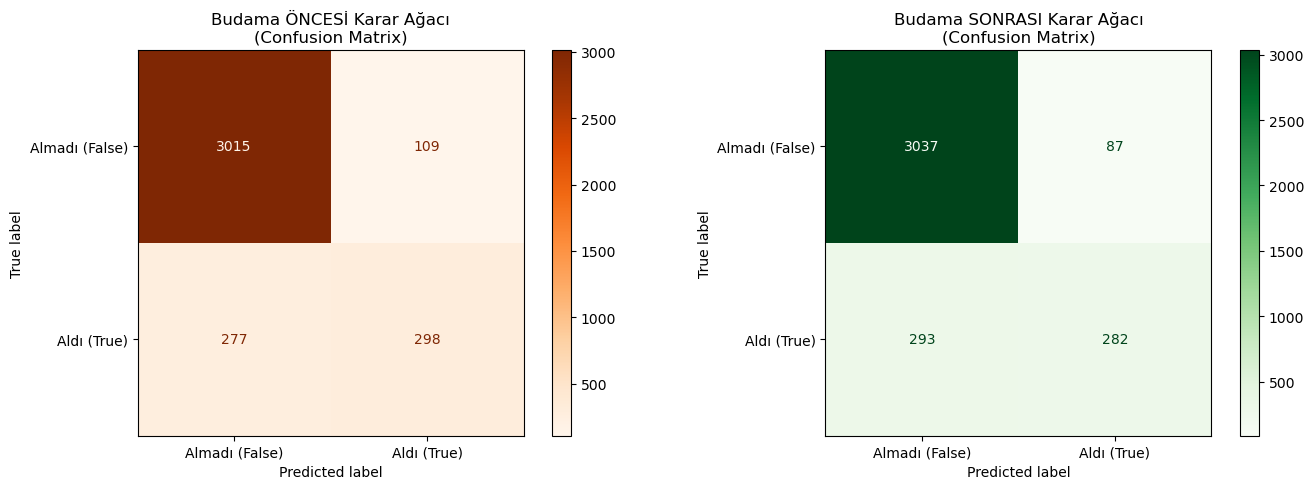

In [21]:
# --- MODEL DEĞERLENDİRME ---

# Performans metin raporları
print("=== BUDAMA ÖNCESİ (GridSearch) PERFORMANS ===")
print(classification_report(y_test, y_pred_before))

print("\n=== BUDAMA SONRASI (Pruned - ccp_alpha) PERFORMANS ===")
print(classification_report(y_test, y_pred_after))

# --- CONFUSION MATRIX GÖRSELLEŞTİRMELERİ  ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Budama ÖNCESİ (GridSearch) Confusion Matrix
cm_before = confusion_matrix(y_test, y_pred_before)
disp_before = ConfusionMatrixDisplay(confusion_matrix=cm_before, display_labels=["Almadı (False)", "Aldı (True)"])
disp_before.plot(cmap='Oranges', ax=axes[0], values_format='d')
axes[0].set_title('Budama ÖNCESİ Karar Ağacı\n(Confusion Matrix)')

# 2. Budama SONRASI (Pruned) Confusion Matrix
cm_after = confusion_matrix(y_test, y_pred_after)
disp_after = ConfusionMatrixDisplay(confusion_matrix=cm_after, display_labels=["Almadı (False)", "Aldı (True)"])
disp_after.plot(cmap='Greens', ax=axes[1], values_format='d')
axes[1].set_title('Budama SONRASI Karar Ağacı\n(Confusion Matrix)')

plt.tight_layout()
plt.show()